# Comapring our models vs the GDPNOW forecast

### Importing needed data and modules

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

RAW = Path("data/raw")
OUT = Path("data/processed")

### Getting csv datasets we obtained from Notebook 2 and 3.

In [2]:
def load_pred(name):
    return pd.read_csv(OUT / name, index_col=0, parse_dates=True)

def load_gdpnow():
    df = pd.read_csv(RAW / "GDPNOW.csv", index_col=0, parse_dates=True)
    s = df.iloc[:, 0]; s.name = "gdpnow"
    s.index = s.index.to_period("Q").to_timestamp("Q")
    return s

### Building the actual comparison table for numerical comparisons

In [3]:
def comparison_frame():
    bridge = load_pred("bridge_predictions.csv")
    ml = load_pred("ml_predictions.csv")
    gdpnow = load_gdpnow()
    df = bridge.join(ml[["dfm_pred", "lstm_pred"]], how="outer")
    df = df.join(gdpnow, how="left")
    return df.dropna(subset=["actual"])

cmp = comparison_frame()
cmp.tail()

,actual,bridge_pred,dfm_pred,lstm_pred,gdpnow
2024-12-31,1.9,3.603691,2.526133,2.328670,2.2711
2025-03-31,-0.6,2.388827,2.159985,0.444125,-2.7318
2025-06-30,3.8,2.594484,1.993163,4.382835,2.9020
2025-09-30,4.4,2.380090,1.758454,1.468000,3.4728
2025-12-31,0.5,3.261940,1.789774,3.995692,4.2373


### Computing RMSE and MAE for gdpnow forecasts too so we can compare numerically as well

In [ ]:
def score_col(df, col):
    sub = df[["actual", col]].dropna()
    return {"model": col,
            "rmse": float(np.sqrt(mean_squared_error(sub["actual"], sub[col]))),
            "mae":  float(mean_absolute_error(sub["actual"], sub[col])),
            "n":    len(sub)}

def score_all(df):
    cols = ["bridge_pred", "dfm_pred", "lstm_pred", "gdpnow"]
    return pd.DataFrame([score_col(df, c) for c in cols])

score_table = score_all(cmp)
score_table

,model,rmse,mae,n
0,bridge_pred,3.833873,1.946940,44
1,dfm_pred,4.327797,2.205028,44
2,lstm_pred,7.098746,3.416496,44
3,gdpnow,1.787482,1.416811,44


### Diebold-Mariano-style significance test

The Dm_like function computes the per-quarter squared-error difference between a given model and GDPNow, then runs a one-sample t-test on those differences. So, our null hypothesis to measure our p-values is that the mean loss differential is zero, meaning the model and GDPNow have equal predictive accuracy. SO if p-value > .05, we can say that we cannot reject the null that our models and FDPnow has equal predictive accuracy -- good for us.


In [ ]:
from scipy import stats

def dm_like(df, model_col, bench_col: str = "gdpnow"):
    sub = df[["actual", model_col, bench_col]].dropna()
    d = (sub[model_col] - sub["actual"])**2 - (sub[bench_col] - sub["actual"])**2
    t, p = stats.ttest_1samp(d, 0.0)
    return {"model": model_col, "mean_loss_diff": float(d.mean()),
            "t": float(t), "p": float(p), "n": len(d)}

def dm_all(df):
    return pd.DataFrame([dm_like(df, m)
                         for m in ["bridge_pred", "dfm_pred", "lstm_pred"]])

dm_all(cmp)

,model,mean_loss_diff,t,p,n
0,bridge_pred,11.503490,1.291219,0.203526,44
1,dfm_pred,15.534739,1.341313,0.186861,44
2,lstm_pred,47.197107,1.510892,0.138131,44


### Actual visual comparions

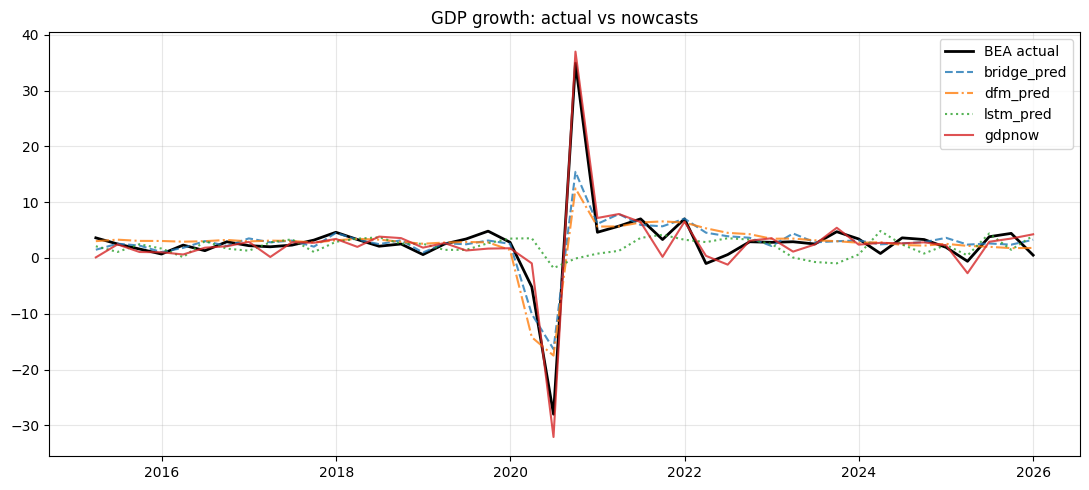

In [6]:
def plot_comparison(df):
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(df.index, df["actual"], label="BEA actual", linewidth=2, color="black")
    for col, style in [("bridge_pred", "--"), ("dfm_pred", "-."),
                       ("lstm_pred", ":"), ("gdpnow", "-")]:
        if col in df:
            ax.plot(df.index, df[col], style, label=col, alpha=0.8)
    ax.set_title("GDP growth: actual vs nowcasts")
    ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

plot_comparison(cmp)

### Showing Errors over time (This is the predicted growth by percentage points - the actual growth by percentage pointd)

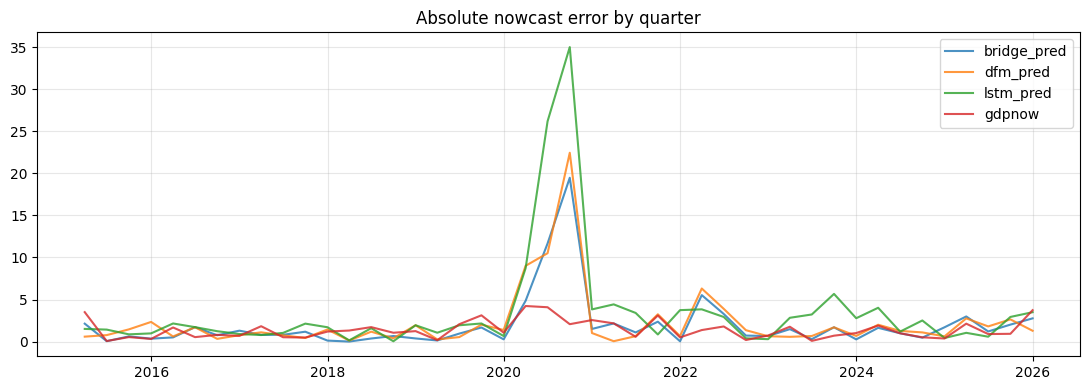

In [7]:
def plot_errors(df):
    fig, ax = plt.subplots(figsize=(11, 4))
    for col in ["bridge_pred", "dfm_pred", "lstm_pred", "gdpnow"]:
        if col in df:
            ax.plot(df.index, (df[col] - df["actual"]).abs(),
                    label=col, alpha=0.8)
    ax.set_title("Absolute nowcast error by quarter")
    ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

plot_errors(cmp)

### Saving all of these results so when we do our writeups dont have to rerun every single time.

In [8]:
def save_final(cmp, scores):
    cmp.to_csv(OUT / "final_comparison.csv")
    scores.to_csv(OUT / "final_scores.csv", index=False)

save_final(cmp, score_table)

# THIS IS more robustness check: I want to see how well model does, if we do not include the 2020 shock.

In [ ]:
COVID_QUARTERS = [pd.Timestamp("2020-06-30"), pd.Timestamp("2020-09-30")]

def drop_covid(df) :
    return df.loc[~df.index.isin(COVID_QUARTERS)]

cmp_excovid = drop_covid(cmp)
cmp_excovid.shape, cmp.shape

((42, 5), (44, 5))

### getting scores excluding covid and then merging with the original scores for direct comparison

In [ ]:
score_table_excovid = score_all(cmp_excovid)
def merge_scores(full, excovid):
    a = full.set_index("model")[["rmse", "mae"]].add_suffix("_full")
    b = excovid.set_index("model")[["rmse", "mae"]].add_suffix("_excovid")
    return a.join(b).reset_index()

score_comparison = merge_scores(score_table, score_table_excovid)
score_comparison

,model,rmse_full,mae_full,rmse_excovid,mae_excovid
0,bridge_pred,3.833873,1.946940,1.769259,1.298267
1,dfm_pred,4.327797,2.205028,2.235655,1.525454
2,lstm_pred,7.098746,3.416496,2.700666,2.122310
3,gdpnow,1.787482,1.416811,1.687584,1.337726


### See direct percentage change from excluding covid and not in rmse and mae. If its a ton then we know the reason for the models being "bad" is from this 2020 shock

In [11]:
def pct_drop(df):
    out = df[["model"]].copy()
    out["rmse_drop_pct"] = (1 - df["rmse_excovid"] / df["rmse_full"]) * 100
    out["mae_drop_pct"] = (1 - df["mae_excovid"] / df["mae_full"]) * 100
    return out.round(1)

pct_drop(score_comparison)

,model,rmse_drop_pct,mae_drop_pct
0,bridge_pred,53.9,33.3
1,dfm_pred,48.3,30.8
2,lstm_pred,62.0,37.9
3,gdpnow,5.6,5.6


### Rerunning the signifcance test

In [12]:
def dm_all_excovid(df):
    return pd.DataFrame([dm_like(df, m)
                         for m in ["bridge_pred", "dfm_pred", "lstm_pred"]])

dm_all_excovid(cmp_excovid)

,model,mean_loss_diff,t,p,n
0,bridge_pred,0.282337,0.339881,0.735681,42
1,dfm_pred,2.150213,1.159995,0.252761,42
2,lstm_pred,4.445659,2.590583,0.013209,42


### Visuals after excluding Covid Shcok

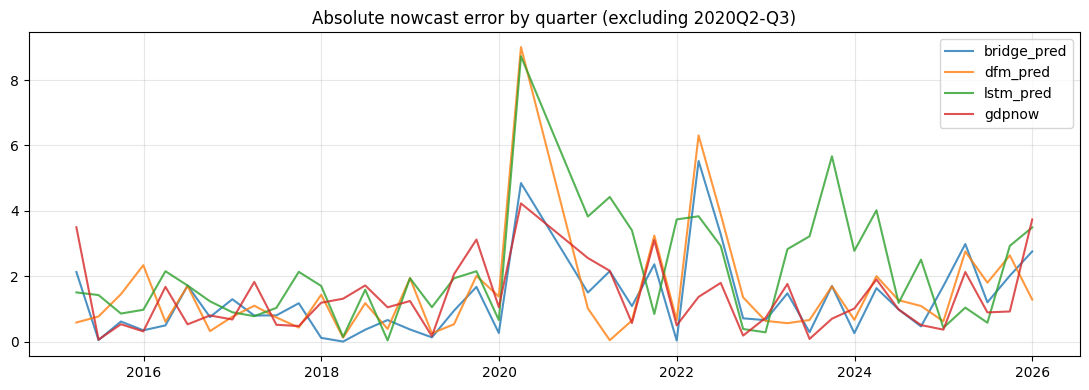

In [13]:
def plot_errors_excovid(df):
    fig, ax = plt.subplots(figsize=(11, 4))
    for col in ["bridge_pred", "dfm_pred", "lstm_pred", "gdpnow"]:
        if col in df:
            ax.plot(df.index, (df[col] - df["actual"]).abs(),
                    label=col, alpha=0.8)
    ax.set_title("Absolute nowcast error by quarter (excluding 2020Q2-Q3)")
    ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

plot_errors_excovid(cmp_excovid)

In [14]:
### Saving robustness check results
def save_robustness(cmp_ex, scores):
    cmp_ex.to_csv(OUT / "final_comparison_excovid.csv")
    scores.to_csv(OUT / "final_scores_comparison.csv", index=False)

save_robustness(cmp_excovid, score_comparison)